# 2 · Models and the 2025-26 forecast
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/twillixa/NBA-Analysis/blob/main/notebooks/02_model_and_forecast.ipynb)

**Part A** reproduces the report's section 4 exactly: a random forest and an OLS regression that map a roster's
average (min-max scaled) player stats and prior-season awards to the team's win %.
**Part B** re-runs the 2025-26 forecast with the projection fixes from notebook 3 and compares it with the report's.

In [1]:
import sys, os
if "google.colab" in sys.modules:  # running on Colab: fetch the repo first
    !git clone -q https://github.com/twillixa/NBA-Analysis
    %cd NBA-Analysis/notebooks
sys.path.insert(0, os.path.abspath("../src"))

import warnings
warnings.simplefilter("ignore", FutureWarning)
warnings.filterwarnings("ignore", message=".*encountered in matmul")  # spurious on macOS Accelerate
import pandas as pd
from nba import plots
from nba.data import build_datasets, CORRECTED
plots.use_style()
pd.set_option("display.precision", 3)
from nba import model as m
from nba.data import load_roster_2026
players, standings = build_datasets()  # report's cleaning

# Part A · The report's models
## Team-season feature table
Players averaging ≥ 5 minutes, each stat min-max scaled across all player-seasons, averaged per team-season → 630 team-seasons × 28 features.

In [2]:
table = m.rf_team_table(players, standings)
print(table.shape)
table.head()

(630, 32)


,Team,Season,FG_norm,FGA_norm,FG%_norm,3P_norm,3PA_norm,3P%_norm,2P_norm,2PA_norm,...,TOV_norm,PF_norm,PTS_norm,TMVP-1_norm,TDPOY-1_norm,MVP-1_norm,DPOY-1_norm,ALL-NBA-1_norm,W%,Rk
0,ATL,2005,0.246,0.251,0.443,0.065,0.080,0.241,0.228,0.260,...,0.233,0.389,0.214,0.0,0.0,0.0,0.000,0.0,0.159,30
1,ATL,2006,0.232,0.230,0.432,0.082,0.088,0.255,0.206,0.229,...,0.213,0.351,0.216,0.0,0.0,0.0,0.000,0.0,0.317,27
2,ATL,2007,0.229,0.236,0.425,0.066,0.084,0.225,0.211,0.239,...,0.217,0.330,0.210,0.0,0.0,0.0,0.000,0.0,0.366,27
3,ATL,2008,0.285,0.288,0.428,0.104,0.116,0.222,0.251,0.283,...,0.243,0.340,0.261,0.0,0.0,0.0,0.077,0.0,0.451,19
4,ATL,2009,0.249,0.247,0.443,0.109,0.121,0.296,0.212,0.230,...,0.172,0.280,0.228,0.0,0.0,0.0,0.071,0.0,0.573,12


## Random forest (report §4.1.2)
100 trees, depth ≤ 10, random 80/20 split.

Test R² = 0.438   (report: 0.439)


ALL-NBA-1    0.277
TOV          0.113
FG%          0.092
FGA          0.054
BLK          0.042
TS%          0.029
DPOY-1       0.029
FT           0.029
FT%          0.027
FTA          0.026
Name: Importance, dtype: float64

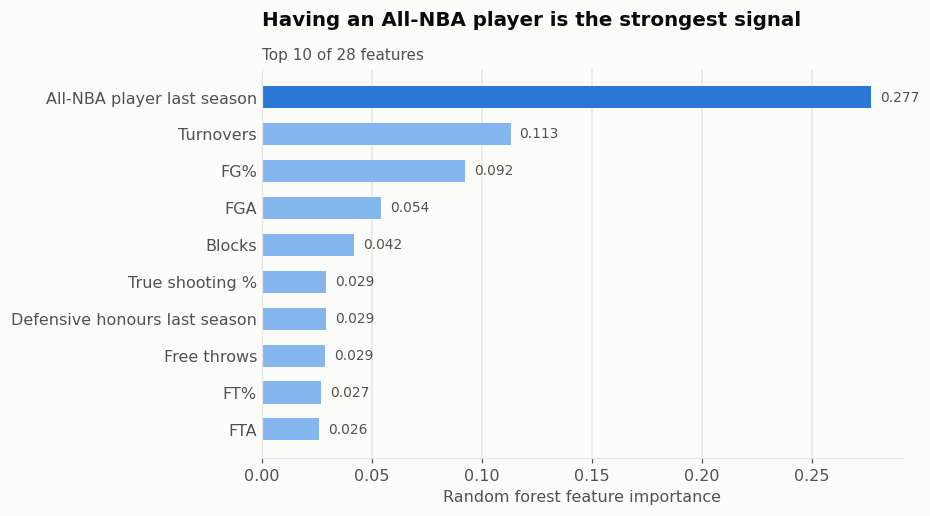

In [3]:
rf, r2, importances = m.fit_rf_holdout(table)
print(f"Test R² = {r2:.3f}   (report: 0.439)")
fig = plots.importances(importances); plots.save(fig, "feature_importance")
importances.head(10).round(3)

**Ranking accuracy.** The report scores its leader table with a forest fit on *all* seasons, i.e. on data it has already seen. Notebook 3 re-scores it on unseen seasons.

In [4]:
table_rf = table.copy()
rf_all = m.rf_model().fit(m.rf_features(table_rf), table_rf["W%"])
table_rf["W%_pred"] = rf_all.predict(m.rf_features(table_rf))
leaders_rf = m.leader_table(m.rank_by_season(table_rf))
print(f"Leader correctly identified: {leaders_rf.Hit.sum()} / {len(leaders_rf)} seasons "
      f"(report: 13/20, in-sample)")
leaders_rf

Leader correctly identified: 13 / 20 seasons (report: 13/20, in-sample)


,Season,Actual_leader,Predicted_leader,Predicted_leader_finished,Hit
0,2006,DET,SAS,2,False
1,2007,DAL,DAL,1,True
2,2008,BOS,BOS,1,True
3,2009,CLE,LAL,2,False
4,2010,CLE,CLE,1,True
5,2011,CHI,SAS,2,False
6,2012,CHI,OKC,3,False
7,2013,MIA,MIA,1,True
8,2014,SAS,SAS,1,True
9,2015,GSW,GSW,1,True


## OLS regression (report §4.1.6)

In [5]:
ols_table = m.ols_team_table(players, standings)
ols = m.fit_ols(ols_table)
ols_table["W%_pred"] = ols.predict(m.sm.add_constant(m.ols_features(ols_table)))
ranks_ols = m.rank_by_season(ols_table)
leaders_ols = m.leader_table(ranks_ols)
print(f"R² = {ols.rsquared:.3f} · rank MAE = {ranks_ols.Rank_error.mean():.2f} · "
      f"leader hits = {leaders_ols.Hit.sum()}/20 · leader rank error = "
      f"{(leaders_ols.Predicted_leader_finished - 1).mean():.2f}")
significant = ols.pvalues[ols.pvalues < 0.05].drop("const", errors="ignore")
ols.params[significant.index].round(2).sort_values()

R² = 0.589 · rank MAE = 4.53 · leader hits = 9/20 · leader rank error = 1.45


2PA_norm    -18.60
3PA_norm    -15.74
TOV_norm     -1.87
PF_norm      -0.45
MVP-1         0.04
DPOY-1        0.04
ALL-NBA-1     0.04
TMVP-1        0.05
STL_norm      0.79
dtype: float64

Most OLS coefficients are not significant: the features are heavily collinear (points, attempts and makes move together), which is also why the forest's importances and the OLS signs don't always agree.

# Part B · Forecasting 2025-26
1. Start from the opening-night rosters the group compiled (`data/raw/rs2026.csv`).
2. For each box-score stat, fit a linear regression on a player's previous three seasons (2009-2025) and project 2026. Rookies get a flat baseline line.
3. Carry 2025 awards over as the lagged award flags.
4. Aggregate to teams, predict win % with a forest trained on all 630 team-seasons, convert to wins and rebalance so the league sums to 1,230.

**The report's run** (reproduced first) had three problems in steps 1-2:
- 118 of 522 roster names didn't match the stats history, and all got the 10-point rookie line. 82 are genuine newcomers (2025 draftees and others), but 36 are established players lost to typos such as "Kari-Anthony Towns" and "Mikai Bridges", missing accents such as Şengün and Porziņģis, and a trailing space after "Victor Wembanyama".
- The projection regressions were trained on the 2026 rows themselves, whose stats are all zero.
- Second- and third-year players had their missing seasons filled with zeros.

In [6]:
report_forecast = m.forecast_2026(players, standings, load_roster_2026())
report_forecast.round(3).to_csv("../reports/predictions_2026_report.csv", index=False)
print("Report forecast reproduced: " + ", ".join(f"{t} {w}" for t, w in report_forecast[["Team", "W_pred"]].head(5).values))

Report forecast reproduced: OKC 54, CLE 54, MIN 52, NYK 51, IND 51


Roster names matched to a stats history: 440 of 522 (report: 404). Unmatched = 2025 draftees and other newcomers.


,Team,W_pred,W_pred_report,change
0,OKC,55,54,1
1,MIL,52,50,2
2,CLE,51,54,-3
3,LAC,51,49,2
4,DET,51,48,3
5,BOS,50,47,3
6,MIN,50,52,-2
7,IND,50,51,-1
8,GSW,50,46,4
9,NYK,49,51,-2


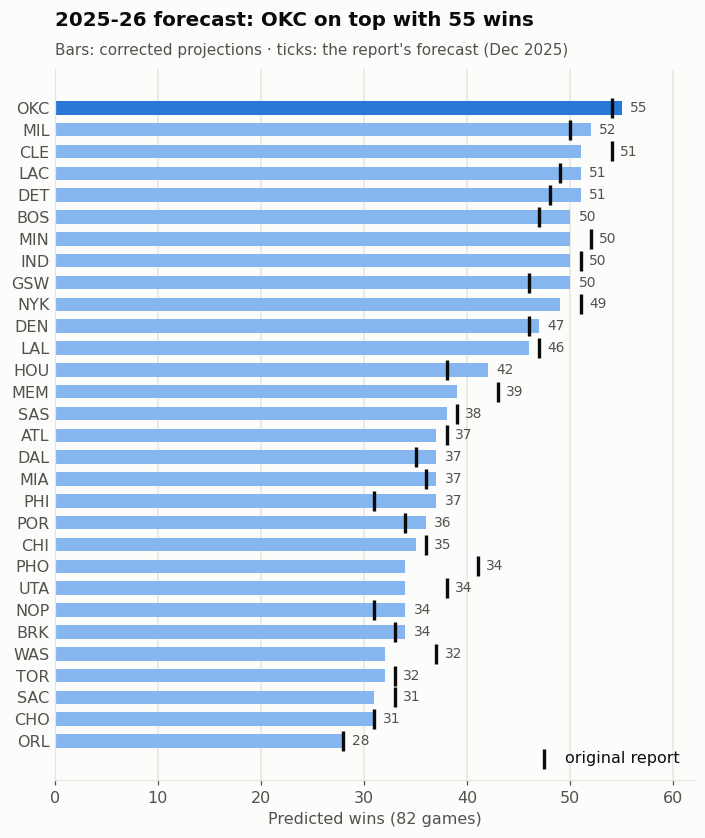

In [7]:
fixed_players, fixed_standings = build_datasets(**CORRECTED)
roster = load_roster_2026(match_names=True, players=fixed_players)
known = set(fixed_players.Player)
print(f"Roster names matched to a stats history: {roster.Player.isin(known).sum()} of {len(roster)} "
      f"(report: {load_roster_2026().Player.isin(set(players.Player)).sum()}). Unmatched = 2025 draftees and other newcomers.")
forecast = m.forecast_2026(fixed_players, fixed_standings, roster, fixes=True, ts_formula="standard")
forecast.round(3).to_csv("../reports/predictions_2026.csv", index=False)
m.rf_team_table(fixed_players, fixed_standings).to_csv("../data/processed/team_seasons.csv", index=False)
fig = plots.forecast(forecast, compare=report_forecast,
                     subtitle="Bars: corrected projections · ticks: the report's forecast (Dec 2025)")
plots.save(fig, "forecast_2026")
both = forecast[["Team", "W_pred"]].merge(report_forecast[["Team", "W_pred"]], on="Team", suffixes=("", "_report"))
both.assign(change=both.W_pred - both.W_pred_report).head(12)

In [8]:
projected = m.project_2026_players(fixed_players, roster, fixes=True, ts_formula="standard")
projected[projected.Season == 2026].nlargest(10, "PTS")[["Player", "Team", "PTS", "TRB", "AST", "MP"]]

,Player,Team,PTS,TRB,AST,MP
12405,Shai Gilgeous-Alexander,OKC,30.0,4.8,5.9,31.5
12172,Giannis Antetokounmpo,MIL,28.2,10.8,6.0,31.7
12050,Luka Dončić,LAL,26.9,7.6,7.2,32.7
12373,Nikola Jokić,DEN,26.8,11.5,9.3,33.3
12388,Anthony Edwards,MIN,25.5,5.3,4.3,33.2
11943,Jayson Tatum,BOS,24.8,7.9,5.4,33.4
11967,Jalen Brunson,NYK,24.7,2.9,6.6,32.6
12210,Kevin Durant,HOU,24.7,5.7,4.1,33.7
11993,Tyrese Maxey,PHI,24.6,3.2,5.6,34.6
12067,Devin Booker,PHO,24.0,3.9,6.5,34.1


Oklahoma City stays on top. Cleveland drops from co-favourite to the 50-win pack, and Phoenix (−7) and Philadelphia (+6) move the most once their stars get real projections instead of rookie lines.